<a href="https://colab.research.google.com/github/GabssMar/preco_imoveis/blob/main/precos_imoveis_corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Avaliativa - Preços de Imóveis**

**Alunos:**
- Gabriele Martinez
- Julia Capellini
- Lucas Gimenez

**Objetivo:** Prever o preço de venda de imóveis residenciais baseado em suas características.

**Contexto do Problema:** A precificação de imóveis é crucial no mercado imobiliário. O preço depende de múltiplos fatores como tamanho, qualidade, localização e amenities.

## Etapa 1 - Análise Exploratória

Primeiro, começamos importando as possíveis bibliotecas que usaremos para iniciar a exploração dos dados.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

Nessa etapa, precisamos entender como os dados do nosso dataset se comportam e como as variáveis se relacionam com o preço do imóvel.

Primeiro, importaremos o dataset de treino para treinarmos o algoritmo.

In [ ]:
# Importando o Dataset de treino
df_imoveis = pd.read_csv('train.csv')

In [5]:
# Mostrando as primeiras linhas para confirmar a importação
df_imoveis.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Aqui, vamos plotar o histograma do preço e verificar as assimetrias.

Podemos verificar que o gráfico está assimétrico, o que significa que a maioria das casas tem preços mais baixos, mas algumas poucas casas bem caras acabam por esticar o gráfico para a direita.

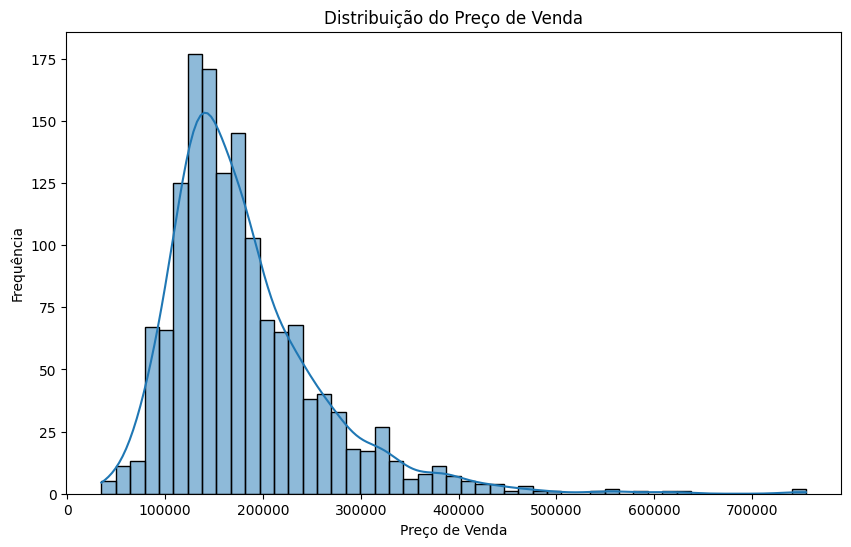

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df_imoveis['SalePrice'], kde=True)
plt.title('Distribuição do Preço de Venda')
plt.xlabel('Preço de Venda')
plt.ylabel('Frequência')
plt.show()

In [7]:
# Calculando a Assimetria (Skewness)
assimetria = df_imoveis['SalePrice'].skew()
print(f"Skewness (Assimetria) de SalePrice: {assimetria:.2f}")

Skewness (Assimetria) de SalePrice: 1.88


Agora, plotaremos um gráfico de dispersão (scatter plot) cruzando a área construída do imóvel com o preço.

Esse gráfico é fundamental para identificar os outliers que teremos que remover na próxima etapa.

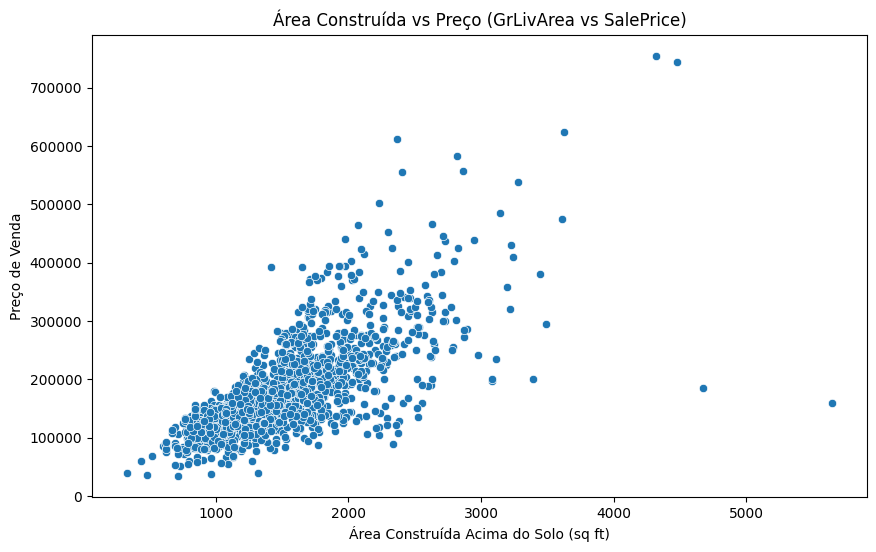

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_imoveis['GrLivArea'], y=df_imoveis['SalePrice'])
plt.title('Área Construída vs Preço (GrLivArea vs SalePrice)')
plt.xlabel('Área Construída Acima do Solo (sq ft)')
plt.ylabel('Preço de Venda')
plt.show()

Com o gráfico, podemos observar que sim, há Outliers, pois temos algumas casas que possuem área maior que 4000 mas com prreços muito baixos.

A seguir, montaremos um boxplot cruzando a qualidade geral do imóvel com o seu preço.

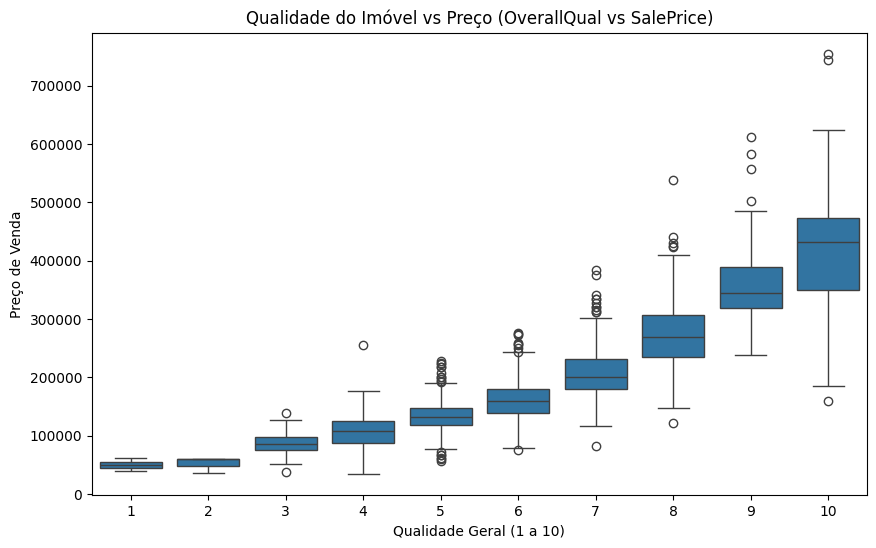

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_imoveis['OverallQual'], y=df_imoveis['SalePrice'])
plt.title("Qualidade do Imóvel vs Preço (OverallQual vs SalePrice)")
plt.xlabel("Qualidade Geral (1 a 10)")
plt.ylabel("Preço de Venda")
plt.show()

Por fim, precisamos ver quais variáveis numéricas têm a correlação mais forte com o preço.

Como nosso dataset tem muitas colunas, vamos pegar apenas as variáveis numéricas e focar nas que mais se relacionam com o preço de venda.

In [10]:
# Selecionando apenas as colunas numéricas
df_numericas = df_imoveis.select_dtypes(include=['int64','float64'])

In [11]:
# Calculando a correlação com o SalePrice e pegar as 10 maiores
correlacoes = df_numericas.corr()
top_features = correlacoes.nlargest(10, 'SalePrice')['SalePrice'].index

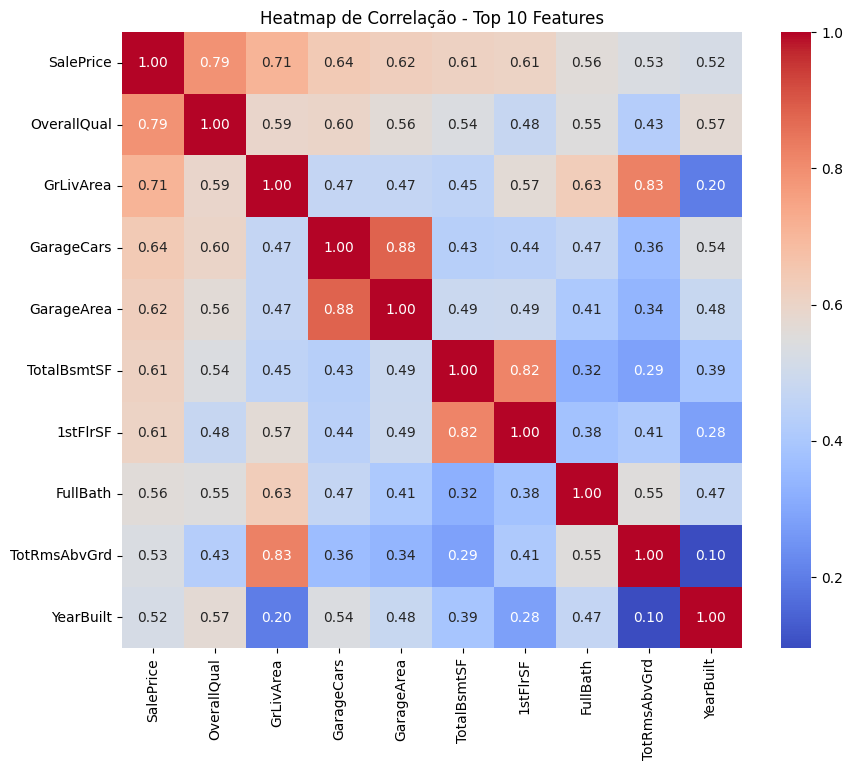

In [12]:
# Plotando o HeatMap das 10 variáveis mais correlacionadas
plt.figure(figsize=(10, 8))
sns.heatmap(df_numericas[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Correlação - Top 10 Features')
plt.show()

### Etapa 2 - Pré Processamento

Nessa etapa, nós limparemos os dados para prepará-los para o modelo, porém tomando cuidado para não cometer o erro de Data Leakage.

Para que isso não ocorra, precisamos aplicar as transformações corretamente.

In [13]:
# Primeiro, vamos remover alguns Outliers específicos, que são Área > 4000 e Preço < 300.000
df_removendo_outliers = df_imoveis.drop(df_imoveis[(df_imoveis['GrLivArea'] > 4000) & (df_imoveis['SalePrice'] < 300000)].index)

In [14]:
# Criando a coluna TotalSF
df_removendo_outliers['TotalSF'] = df_removendo_outliers['TotalBsmtSF'] + df_removendo_outliers['1stFlrSF'] + df_removendo_outliers['2ndFlrSF']

Como vimos no Histograma, o preço possui uma assimetria positiva. Para isso, vamos aplica uma transformação logaritmixa para aproximar os dados de uma distribuição normal.

In [15]:
# Aplicando a transformação log1p no target
y = np.log1p(df_removendo_outliers['SalePrice'])

In [16]:
# Separando as variáveis de entrada (features)
X = df_removendo_outliers.drop('SalePrice', axis=1)

A revisão precisa ser feita antes do cálculo das médas para preencher os nulos ou escalonar os dados, se não as informações do teste "vazam" para o treino.

Para isso, faremos a distribuição 60/20/20.

In [17]:
# Passo 1: Separando 60% para treino e 40% temporário
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

In [18]:
# Passo 2: Dividir os 40% restantes na metaded (20% Validação e 20% Teste)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [19]:
print(f"Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")

Treino: 874 | Validação: 292 | Teste: 292


Para tratar os valores ausentes, vamos aplicar o escalonamento numérico e os Encodings. Para isso, vamos usar a estrutura de Pipeline e ColumnTransformer.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [21]:
# Definindo quais colunas são numéricas, ordinais e nominais
colunas_num = ['TotalSF', 'GrLivArea', 'GarageCars', 'OverallQual']
colunas_ord = ['ExterQual']
colunas_nom = ['Neighborhood', 'SaleCondition']

In [22]:
# Pipeline Numérico, aqui preenchemos os nulos com a mediana e padronizamos (Z-Score)
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [23]:
# Pipelina Ordinal: Preenche nulos com moda e aplica OrdinalEncoder
pipe_ord = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

In [24]:
# Pipeline Nominal: Preenche nulos com moda e aplica OneHotEncoder
pipe_nom = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [25]:
# Incluindo tudo no ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', pipe_num, colunas_num),
    ('ord', pipe_ord, colunas_ord),
    ('nom', pipe_nom, colunas_nom)
])

In [26]:
# Usamos o fit_transform só no treino, na validação e no teste usamos apenas transform
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("Pré-processamento concluído com sucesso e sem Data Leakage!")

Pré-processamento concluído com sucesso e sem Data Leakage!


### Etapa 3 - Comparação de Modelos

Nessa etapa, precisamos implementar três modelos, utilizar a validação cruzada K-Fold com K=5, gerar uma tabela com as métricas MAE, MSE, RMSE, R² e MAPE e plotar três gráficos, contendo Valores Reais vs. Preditos, Gráfico de Resíduos e Feature Importance.

In [27]:
# Inicializando os 3 modelos exigidos
modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(random_state=42)
}

In [28]:
# Configurando o K-Fold com K-5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== VALIDAÇÃO CRUZADA (R² Médio no Treino) ===")
for nome, modelo in modelos.items():
  # Avaliando os modelos usando o R²
  cv_scores = cross_val_score(modelo, X_train_prep, y_train, cv=kf, scoring='r2')
  print(f"{nome}: {cv_scores.mean():.4f}")

=== VALIDAÇÃO CRUZADA (R² Médio no Treino) ===
Linear Regression: 0.8614
Ridge: 0.8617
Random Forest: 0.8290


Agora iremos treinar os modelos de fato, prever os valores da base de validação e calcular as métricas exigidas.

In [29]:
# Criando dicionários para guardar as previsões para os gráficos depois
resultados_reais = {}
resultados_preditos = {}

print("=== Métricas na Base de Validação")
for nome, modelo in modelos.items():
  # Treina o modelo com os dados de treino preparados
  modelo.fit(X_train_prep, y_train)

  # Faz a previsão na base de validação
  y_pred_log = modelo.predict(X_val_prep)

  # Revertendo o Logaritmo para ter o preço real em dinheiro
  y_val_real = np.expm1(y_val)
  y_pred_real = np.expm1(y_pred_log)

  # Guardando para os gráficos
  resultados_reais[nome] = y_val_real
  resultados_preditos[nome] = y_pred_real

  # Calculando as métricas exigidas
  mae = mean_absolute_error(y_val_real, y_pred_real)
  mse = mean_squared_error(y_val_real, y_pred_real)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_val_real, y_pred_real)
  mape = mean_absolute_percentage_error(y_val_real, y_pred_real)

  # Exibindo a tabela
  print(f"\nModelo: {nome}")
  print(f"MAE:  {mae:,.2f}")
  print(f"MSE:  {mse:,.2f}")
  print(f"RMSE: {rmse:,.2f}")
  print(f"R²:   {r2:.4f}")
  print(f"MAPE: {mape:.4f} ({mape*100:.2f}%)")

=== Métricas na Base de Validação

Modelo: Linear Regression
MAE:  18,345.91
MSE:  607,660,651.53
RMSE: 24,650.77
R²:   0.9159
MAPE: 0.1137 (11.37%)

Modelo: Ridge
MAE:  18,429.30
MSE:  611,492,772.67
RMSE: 24,728.38
R²:   0.9153
MAPE: 0.1144 (11.44%)

Modelo: Random Forest
MAE:  20,304.28
MSE:  1,022,244,670.32
RMSE: 31,972.56
R²:   0.8585
MAPE: 0.1215 (12.15%)


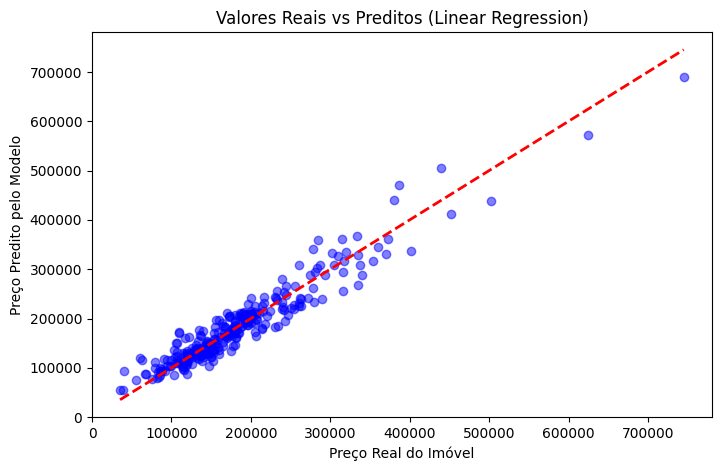

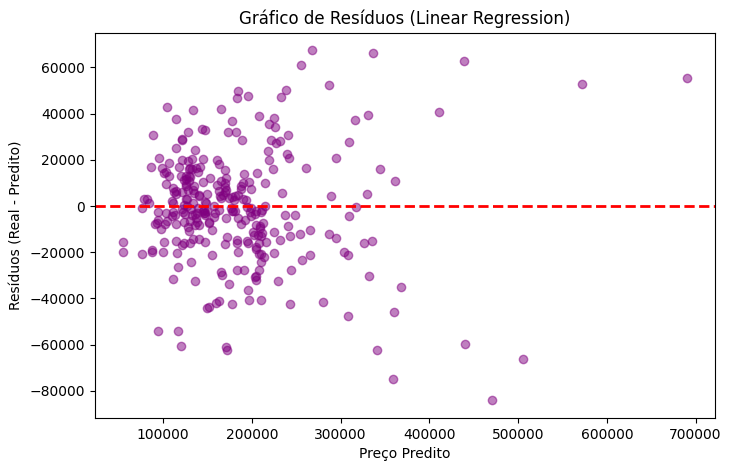

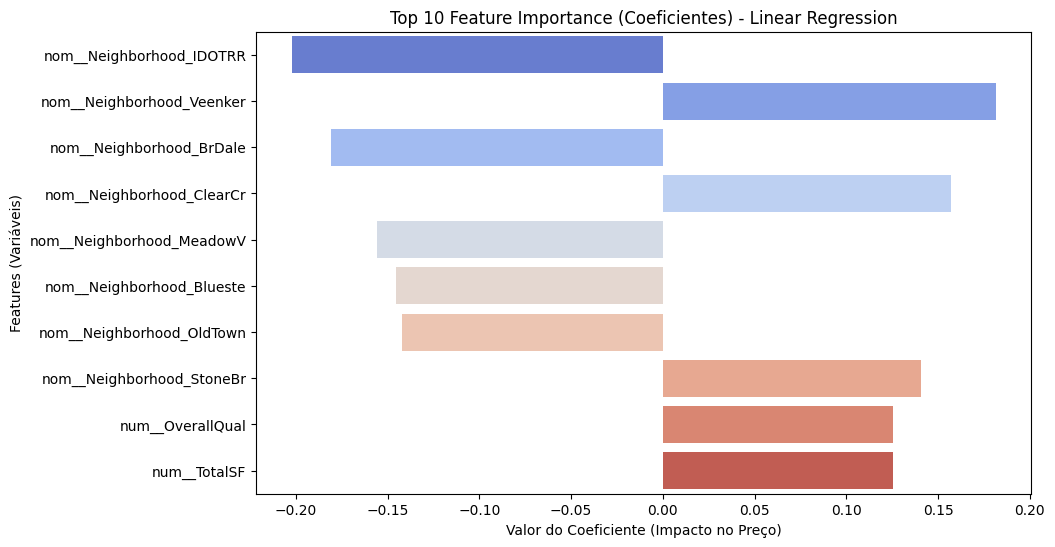

In [30]:
# Usando o Linear Regression para os gráficos
y_real_rf = resultados_reais['Linear Regression']
y_pred_rf = resultados_preditos['Linear Regression']
residuos = y_real_rf - y_pred_rf

# Gráfico de Valores Reais vs. Preditos
plt.figure(figsize=(8, 5))
plt.scatter(y_real_rf, y_pred_rf, alpha=0.5, color='blue')
# Linha de acerto perfeito (diagonal)
plt.plot([y_real_rf.min(), y_real_rf.max()], [y_real_rf.min(), y_real_rf.max()], 'r--', lw=2)
plt.title('Valores Reais vs Preditos (Linear Regression)')
plt.xlabel('Preço Real do Imóvel')
plt.ylabel('Preço Predito pelo Modelo')
plt.show()

# Gráfico de Resíduos (Erros)
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_rf, residuos, alpha=0.5, color='purple')
plt.axhline(0, color='r', linestyle='--', lw=2) # Linha do erro zero
plt.title('Gráfico de Resíduos (Linear Regression)')
plt.xlabel('Preço Predito')
plt.ylabel('Resíduos (Real - Predito)')
plt.show()

# Gráfico de Feature Importance (Importância das Variáveis - COEFICIENTES)
coeficientes = modelos['Linear Regression'].coef_
# Pegando os nomes das colunas geradas pelo ColumnTransformer
nomes_features = preprocessor.get_feature_names_out()

# Criando uma série Pandas com os coeficientes
feat_imp = pd.Series(coeficientes, index=nomes_features)

# Ordenando pelo valor absoluto para pegar as 10 variáveis de MAIOR IMPACTO (positivo ou negativo)
feat_imp_ordenada = feat_imp.reindex(feat_imp.abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(10, 6))
# Mudamos a paleta para 'coolwarm' para ver mais fácil o que é positivo e negativo
sns.barplot(x=feat_imp_ordenada.values, y=feat_imp_ordenada.index, hue=feat_imp_ordenada.index, legend=False, palette='coolwarm')
plt.title('Top 10 Feature Importance (Coeficientes) - Linear Regression')
plt.xlabel('Valor do Coeficiente (Impacto no Preço)')
plt.ylabel('Features (Variáveis)')
plt.show()

### Etapa 4 - Análise Comparativa e Avaliação Final

Com os modelos treinados e avaliados na base de validação, agora vamos aprofundar a análise: identificar o melhor modelo, realizar o tuning de hiperparâmetros e, por fim, avaliá-lo no conjunto de teste.

#### Tuning de Hiperparâmetros (GridSearchCV)

Antes de avaliar no teste, vamos refinar o Random Forest, que apresentou os melhores resultados na validação. Usaremos o GridSearchCV para encontrar a combinação ideal de hiperparâmetros.

In [31]:
from sklearn.model_selection import GridSearchCV

# Definindo o grid de hiperparâmetros para o Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Aplicando o GridSearchCV com KFold (k=5) no conjunto de treino
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_prep, y_train)

print("Melhores hiperparâmetros encontrados:")
print(rf_grid.best_params_)
print(f"\nMelhor R² na validação cruzada (treino): {rf_grid.best_score_:.4f}")

Melhores hiperparâmetros encontrados:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Melhor R² na validação cruzada (treino): 0.8315


Com os melhores hiperparâmetros em mãos, vamos agora avaliar o modelo otimizado na base de validação para confirmar a melhoria.

In [32]:
# Avaliando o modelo otimizado na base de validação
y_pred_rf_otimizado_log = rf_grid.best_estimator_.predict(X_val_prep)
y_pred_rf_otimizado_real = np.expm1(y_pred_rf_otimizado_log)
y_val_real = np.expm1(y_val)

mae_ot = mean_absolute_error(y_val_real, y_pred_rf_otimizado_real)
rmse_ot = np.sqrt(mean_squared_error(y_val_real, y_pred_rf_otimizado_real))
r2_ot = r2_score(y_val_real, y_pred_rf_otimizado_real)

print("=== Random Forest Otimizado (Validação) ===")
print(f"MAE:  {mae_ot:,.2f}")
print(f"RMSE: {rmse_ot:,.2f}")
print(f"R²:   {r2_ot:.4f}")

=== Random Forest Otimizado (Validação) ===
MAE:  20,363.17
RMSE: 31,647.64
R²:   0.8613


#### Avaliação Final no Conjunto de Teste

Agora chegou a hora de usar o conjunto de teste, que ficou completamente isolado durante todo o processo.

In [33]:
# Avaliando o melhor modelo (Random Forest otimizado) na base de TESTE
y_pred_teste_log = rf_grid.best_estimator_.predict(X_test_prep)

# Revertendo o logaritmo para obter os preços reais
y_test_real = np.expm1(y_test)
y_pred_teste_real = np.expm1(y_pred_teste_log)

mae_test = mean_absolute_error(y_test_real, y_pred_teste_real)
mse_test = mean_squared_error(y_test_real, y_pred_teste_real)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test_real, y_pred_teste_real)
mape_test = mean_absolute_percentage_error(y_test_real, y_pred_teste_real)

print("=== Avaliação Final: Random Forest Otimizado (Teste) ===")
print(f"MAE:  {mae_test:,.2f}")
print(f"MSE:  {mse_test:,.2f}")
print(f"RMSE: {rmse_test:,.2f}")
print(f"R²:   {r2_test:.4f}")
print(f"MAPE: {mape_test:.4f} ({mape_test*100:.2f}%)")

=== Avaliação Final: Random Forest Otimizado (Teste) ===
MAE:  18,204.42
MSE:  622,666,448.95
RMSE: 24,953.29
R²:   0.8829
MAPE: 0.1057 (10.57%)


Plotamos abaixo os gráficos de Valores Reais vs. Preditos e de Resíduos para o conjunto de teste, para verificar se o comportamento do modelo se mantém consistente com o que observamos na validação.

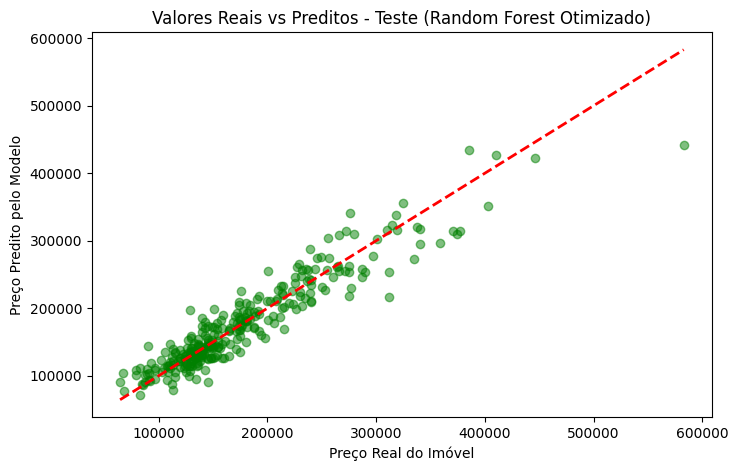

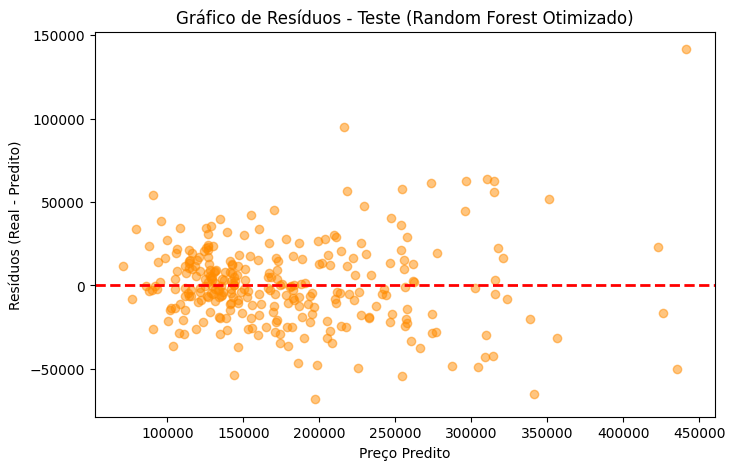

In [34]:
residuos_teste = y_test_real - y_pred_teste_real

# Gráfico Reais vs Preditos no Teste
plt.figure(figsize=(8, 5))
plt.scatter(y_test_real, y_pred_teste_real, alpha=0.5, color='green')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.title('Valores Reais vs Preditos - Teste (Random Forest Otimizado)')
plt.xlabel('Preço Real do Imóvel')
plt.ylabel('Preço Predito pelo Modelo')
plt.show()

# Gráfico de Resíduos no Teste
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_teste_real, residuos_teste, alpha=0.5, color='darkorange')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Gráfico de Resíduos - Teste (Random Forest Otimizado)')
plt.xlabel('Preço Predito')
plt.ylabel('Resíduos (Real - Predito)')
plt.show()

#### Análise dos Padrões dos Resíduos

Observando o gráfico de resíduos, podemos identificar em que faixas de preço o modelo erra mais e se há padrões sistemáticos nos erros.

=== Erro Absoluto Médio por Faixa de Preço ===
Faixa de Preço
< 100k        16194.786271
100k-200k     14332.514113
200k-300k     21960.213874
300k-500k     37758.476799
> 500k       141500.801601


/tmp/ipykernel_11310/2486698494.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Faixa de Preço', y='Resíduo', data=df_residuos, palette='Set2')


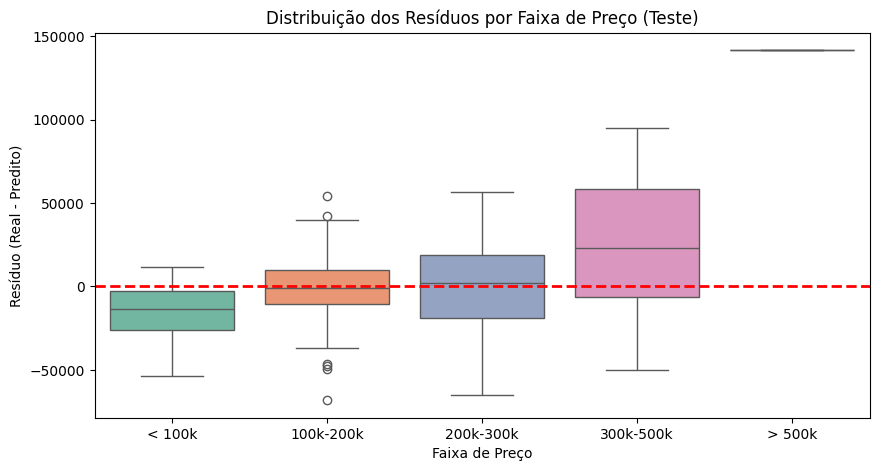

In [35]:
# Analisando os resíduos por faixa de preço
faixas = pd.cut(y_test_real, bins=[0, 100000, 200000, 300000, 500000, float('inf')],
                labels=['< 100k', '100k-200k', '200k-300k', '300k-500k', '> 500k'])

df_residuos = pd.DataFrame({
    'Preço Real': y_test_real.values,
    'Resíduo': residuos_teste.values,
    'Faixa de Preço': faixas.values
})

# Erro absoluto médio por faixa
erro_por_faixa = df_residuos.groupby('Faixa de Preço', observed=True)['Resíduo'].apply(lambda x: x.abs().mean())

print("=== Erro Absoluto Médio por Faixa de Preço ===")
print(erro_por_faixa.to_string())

# Plotando o boxplot dos resíduos por faixa
plt.figure(figsize=(10, 5))
sns.boxplot(x='Faixa de Preço', y='Resíduo', data=df_residuos, palette='Set2')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Distribuição dos Resíduos por Faixa de Preço (Teste)')
plt.xlabel('Faixa de Preço')
plt.ylabel('Resíduo (Real - Predito)')
plt.show()